### 1. Imports

In [20]:
%matplotlib inline 
# To enable inline plotting in Jupyter notebooks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import homogeneity_score
from sklearn.cluster import k_means
from sklearn.decomposition import PCA

### 2. Dataset Imports

In [21]:
path = "../data/nutrition.csv"
df_notLabeled = pd.read_csv(filepath_or_buffer=path, sep=',', engine='python')
path = "../data/nutrition_labeled.csv"
df_Labeled = pd.read_csv(filepath_or_buffer=path, sep=',')

# Display the first few rows of the unlabeled dataset
display(df_notLabeled.head(5))


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [22]:
# Display the first few rows of the labeled dataset
display(df_Labeled.head(5))

,id,calories,proteins,fat,carbohydrate,name,image,energy_protein,energy_fat,energy_carb,...,pct_protein,pct_fat,pct_carb,label,crit_fat_le_30,crit_carb_45_65,crit_protein_10_20,crit_cal_lt_250,energy_diff_abs,energy_diff_pct
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...,36.8,255.6,0.0,...,12.585499,87.414501,0.000000,Baik,False,False,True,False,12.4,4.240766
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...,94.8,333.0,85.2,...,18.479532,64.912281,16.608187,Sangat Buruk,False,False,True,False,0.0,0.000000
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,0.0,1.8,0.0,...,0.000000,100.000000,0.000000,Sangat Buruk,False,False,False,True,1.8,100.000000
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...,4.4,3.6,43.2,...,8.593750,7.031250,84.375000,Baik,True,False,False,True,6.2,12.109375
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...,17.6,4.5,15.2,...,47.184987,12.064343,40.750670,Baik,True,False,False,True,0.3,0.804290


### 3. Dataset Cleaning

- Dataset Information

In [23]:
display(df_notLabeled.info())
display(df_Labeled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1346 non-null   int64  
 1   calories            1346 non-null   float64
 2   proteins            1346 non-null   float64
 3   fat                 1346 non-null   float64
 4   carbohydrate        1346 non-null   float64
 5   name                1346 non-null   object 
 6   image               1346 non-null   object 
 7   energy_protein      1346 non-null   float64
 8   energy_fat          1346 non-null   float64
 9   energy_carb         1346 non-null   float64
 10  energy_from_macros  1346 non-null   float64
 11  pct_protein         1346 non-null   float64
 12  pct_fat             1346 non-null   float64
 13  pct_carb            1346 non-null   float64
 14  label               1346 non-null   object 
 15  crit_fat_le_30      1346 non-null   bool   
 16  crit_c

None

- Check if theres missing values

In [24]:
display(df_Labeled.isnull().sum())
display(df_notLabeled.isnull().sum())
df_notLabeled = df_notLabeled.dropna()
df_Labeled = df_Labeled.dropna()

id                    0
calories              0
proteins              0
fat                   0
carbohydrate          0
name                  0
image                 0
energy_protein        0
energy_fat            0
energy_carb           0
energy_from_macros    0
pct_protein           0
pct_fat               0
pct_carb              0
label                 0
crit_fat_le_30        0
crit_carb_45_65       0
crit_protein_10_20    0
crit_cal_lt_250       0
energy_diff_abs       0
energy_diff_pct       0
dtype: int64

id              0
calories        0
proteins        0
fat             0
carbohydrate    0
name            0
image           0
dtype: int64

- Normalizing Data

Akan menggunakan StandardScaler karena .....

In [25]:
from sklearn.preprocessing import StandardScaler

# drop non-feature columns if present
if 'name' in df_Labeled.columns and 'image' in df_Labeled.columns:
    df_Labeled = df_Labeled.drop(columns=['id','name', 'image'])
    df_notLabeled = df_notLabeled.drop(columns=['id','name', 'image'])

# select numeric columns from each dataframe
num_cols_l = df_Labeled.select_dtypes(include=[np.number]).columns.tolist()
num_cols_n = df_notLabeled.select_dtypes(include=[np.number]).columns.tolist()

# use a common scaler for numeric columns that exist in both dataframes
common_cols = [c for c in num_cols_l if c in num_cols_n]

scaler = StandardScaler()
if common_cols:
    df_Labeled[common_cols] = scaler.fit_transform(df_Labeled[common_cols])
    df_notLabeled[common_cols] = scaler.transform(df_notLabeled[common_cols])

# scale any remaining numeric columns that exist only in df_Labeled
extra_cols = [c for c in num_cols_l if c not in common_cols]
if extra_cols:
    scaler2 = StandardScaler()
    df_Labeled[extra_cols] = scaler2.fit_transform(df_Labeled[extra_cols])
    
# Show head of scaled data
display(df_Labeled.head(5))
display(df_notLabeled.head(5))

,calories,proteins,fat,carbohydrate,energy_protein,energy_fat,energy_carb,energy_from_macros,pct_protein,pct_fat,pct_carb,label,crit_fat_le_30,crit_carb_45_65,crit_protein_10_20,crit_cal_lt_250,energy_diff_abs,energy_diff_pct
0,0.471016,-0.067648,1.516319,-0.788979,-0.067648,1.516319,-0.788979,0.441620,-0.483624,2.582256,-1.565793,Baik,False,False,True,False,-0.023337,-0.093152
1,1.900334,1.156645,2.142778,-0.127099,1.156645,2.142778,-0.127099,1.621368,-0.222008,1.660320,-1.066953,Sangat Buruk,False,False,True,False,-0.167831,-0.179062
2,-1.246619,-0.844440,-0.537882,-0.788979,-0.844440,-0.537882,-0.788979,-1.112480,-1.042252,3.097895,-1.565793,Sangat Buruk,False,False,False,True,-0.146856,1.846734
3,-0.970570,-0.751562,-0.523313,-0.453378,-0.751562,-0.523313,-0.453378,-0.848294,-0.660804,-0.711118,0.968478,Baik,True,False,False,True,-0.095584,0.066250
4,-1.019646,-0.472930,-0.516029,-0.670897,-0.472930,-0.516029,-0.670897,-0.922630,1.052131,-0.504907,-0.341814,Baik,True,False,False,True,-0.164335,-0.162768


,calories,proteins,fat,carbohydrate
0,0.471016,-0.067648,1.516319,-0.788979
1,1.900334,1.156645,2.142778,-0.127099
2,-1.246619,-0.844440,-0.537882,-0.788979
3,-0.970570,-0.751562,-0.523313,-0.453378
4,-1.019646,-0.472930,-0.516029,-0.670897


- Check & Handle data skewness

In [38]:
# Outlier Detection and Handling
from scipy import stats
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df
def handle_outliers_zscore(df, column):
    z_scores = stats.zscore(df[column])
    abs_z_scores = np.abs(z_scores)
    filtered_entries = (abs_z_scores < 3)
    return df[filtered_entries]

# Test Outlier Handling
df_test = df_Labeled.copy()
df_test = handle_outliers_iqr(df_test, 'calories')
display(df_test.head(5))

df_test_notlabeled = handle_outliers_zscore(df_notLabeled, 'calories')
display(df_test_notlabeled.head(5))

df_Labeled = df_test
df_notLabeled = df_test_notlabeled

,calories,proteins,fat,carbohydrate,energy_protein,energy_fat,energy_carb,energy_from_macros,pct_protein,pct_fat,pct_carb,label,crit_fat_le_30,crit_carb_45_65,crit_protein_10_20,crit_cal_lt_250,energy_diff_abs,energy_diff_pct
0,0.471016,-0.067648,1.516319,-0.788979,-0.067648,1.516319,-0.788979,0.441620,-0.483624,2.582256,-1.565793,Baik,False,False,True,False,-0.023337,-0.093152
1,1.900334,1.156645,2.142778,-0.127099,1.156645,2.142778,-0.127099,1.621368,-0.222008,1.660320,-1.066953,Sangat Buruk,False,False,True,False,-0.167831,-0.179062
2,-1.246619,-0.844440,-0.537882,-0.788979,-0.844440,-0.537882,-0.788979,-1.112480,-1.042252,3.097895,-1.565793,Sangat Buruk,False,False,False,True,-0.146856,1.846734
3,-0.970570,-0.751562,-0.523313,-0.453378,-0.751562,-0.523313,-0.453378,-0.848294,-0.660804,-0.711118,0.968478,Baik,True,False,False,True,-0.095584,0.066250
4,-1.019646,-0.472930,-0.516029,-0.670897,-0.472930,-0.516029,-0.670897,-0.922630,1.052131,-0.504907,-0.341814,Baik,True,False,False,True,-0.164335,-0.162768


,calories,proteins,fat,carbohydrate
0,0.471016,-0.067648,1.516319,-0.788979
1,1.900334,1.156645,2.142778,-0.127099
2,-1.246619,-0.844440,-0.537882,-0.788979
3,-0.970570,-0.751562,-0.523313,-0.453378
4,-1.019646,-0.472930,-0.516029,-0.670897


### 4. Exploration Data Analysis Distribution
- Will focus on Labeled since value in notLabeled is the exact same

- Comparing calories, proteins, fat, and carbohydrate

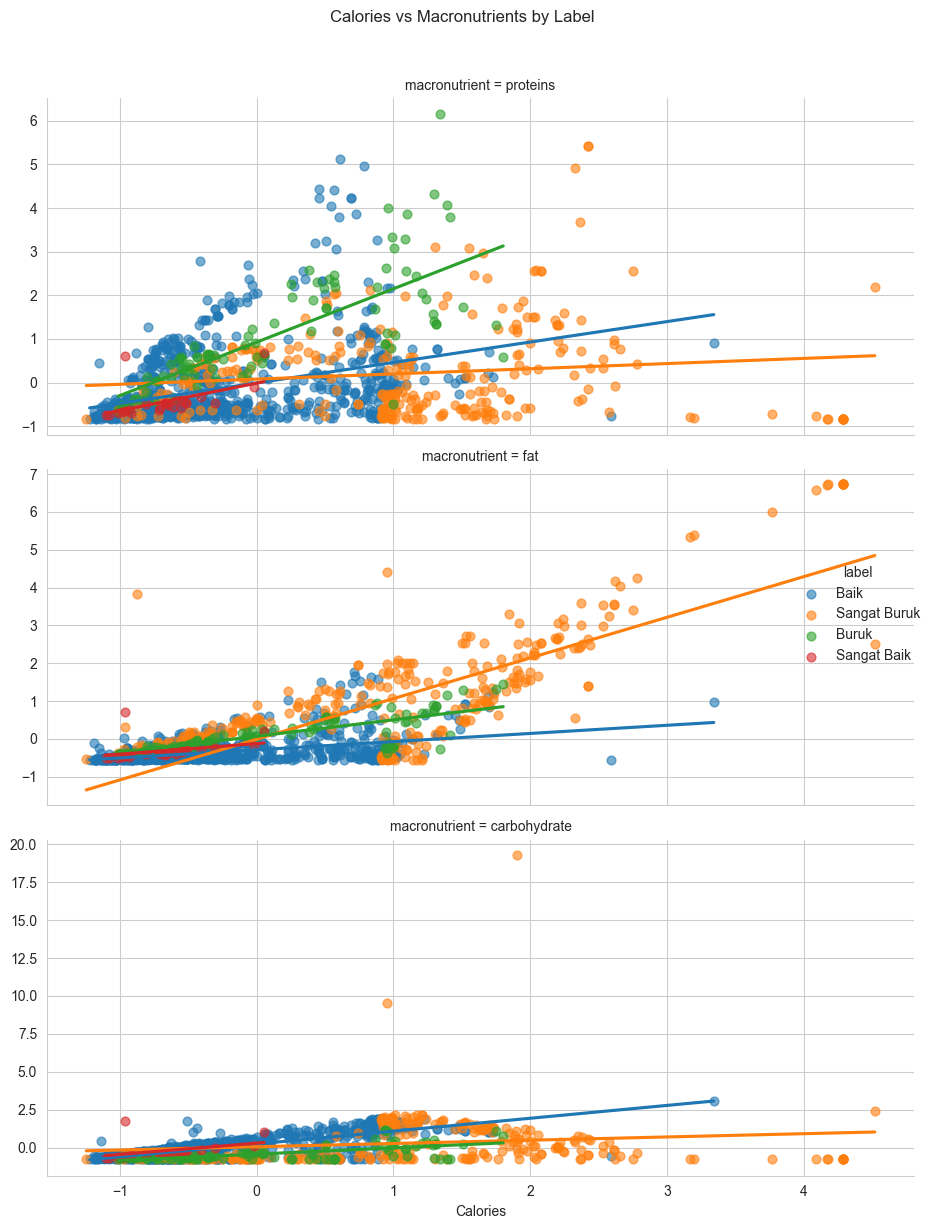

In [27]:
sns.set_style("whitegrid")
# melt dataframe to compare proteins, fat, and carbohydrate against calories
melt_df = df_Labeled.melt(
    id_vars=['calories', 'label'],
    value_vars=['proteins', 'fat', 'carbohydrate'],
    var_name='macronutrient',
    value_name='amount'
)

g = sns.lmplot(
    data=melt_df,
    x='calories',
    y='amount',
    hue='label',
    row='macronutrient',
    row_order=['proteins', 'fat', 'carbohydrate'],
    height=4,
    aspect=2.0,
    scatter_kws={'alpha': 0.6, 's': 40},
    ci=None,
    facet_kws={'sharey': False, 'sharex': True}
)

# set descriptive y-labels per facet
y_labels = {'proteins': 'Proteins (g)', 'fat': 'Fat (g)', 'carbohydrate': 'Carbohydrate (g)'}
for ax, nut in zip(g.axes.flatten(), ['proteins', 'fat', 'carbohydrate']):
    ax.set_ylabel(y_labels[nut])
    
g.set_axis_labels("Calories", "")
g.figure.suptitle("Calories vs Macronutrients by Label", y=1.02)

plt.tight_layout()
plt.show()


- Heatmap

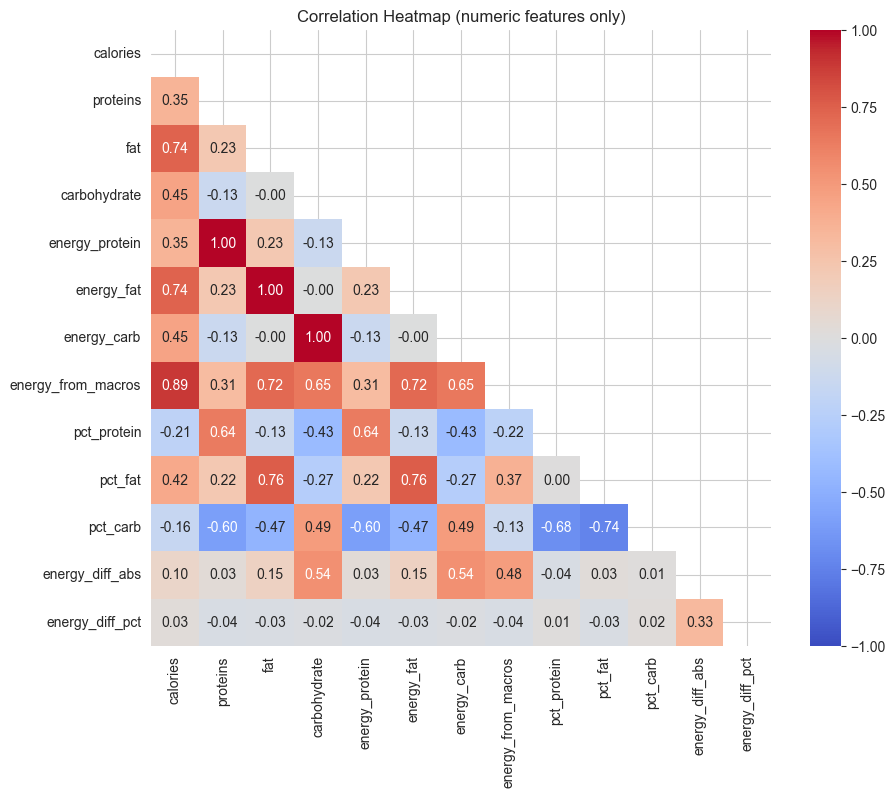

In [28]:
# CORRELATION HEATMAP BETWEEN NUMERIC FEATURES ONLY
# select numeric columns to avoid trying to convert string columns (e.g. 'name') to float
numeric_df = df_Labeled.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
# mask upper triangle for better readability
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (numeric features only)')
plt.show()

## 5. Model Comparison

In [29]:
# Kita gunakan kolom numerik yang sudah discale sebagai fitur (X)
# Pastikan tidak memasukkan kolom 'id', 'label', dan kolom hasil perhitungan 'energy...' jika itu bocoran
# Berdasarkan notebook Anda, kolom fitur utamanya adalah: calories, proteins, fat, carbohydrate
feature_cols = ['calories', 'proteins', 'fat', 'carbohydrate']

X = df_Labeled[feature_cols]
y = df_Labeled['label']

# Buat def split data dengan parameter test_size
def split_and_display(test_size):
    """Splits the data into training and testing sets and displays their sizes."""
    X_data = X
    y_data = y
        
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)} for test_size={test_size}")
    return X_train, X_test, y_train, y_test

- K-Means

In [30]:
# Split data dengan test_size 0.2
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)


# Prediksi cluster untuk data test yang sama dengan supervised learning (agar adil)
kmeans_clusters = k_means(X_test, n_clusters=3, random_state=42)[1]

# Kita buat DataFrame untuk membandingkan Cluster K-Means vs Label Asli
comparison_df = pd.DataFrame({'Real_Label': y_test, 'KMeans_Cluster': kmeans_clusters})

# Melihat distribusi label di setiap cluster
print("=== K-Means Clustering vs Real Labels ===")
print(pd.crosstab(comparison_df['KMeans_Cluster'], comparison_df['Real_Label']))

# Metrik Evaluasi Clustering (Homogeneity Score)
# Skor 1.0 berarti setiap cluster hanya berisi anggota dari satu kelas saja (murni)
h_score = homogeneity_score(y_test, kmeans_clusters)
print(f"\nHomogeneity Score: {h_score:.4f}")

Train size: 1076, Test size: 270 for test_size=0.2
=== K-Means Clustering vs Real Labels ===
Real_Label      Baik  Buruk  Sangat Baik  Sangat Buruk
KMeans_Cluster                                        
0                146     11            7            10
1                 39      2            0            11
2                  7     11            0            26

Homogeneity Score: 0.2059


In [31]:
# Split data dengan test_size 0.5
X_train, X_test, y_train, y_test = split_and_display(test_size=0.5)


# Prediksi cluster untuk data test yang sama dengan supervised learning (agar adil)
kmeans_clusters = k_means(X_test, n_clusters=3, random_state=42)[1]

# Kita buat DataFrame untuk membandingkan Cluster K-Means vs Label Asli
comparison_df = pd.DataFrame({'Real_Label': y_test, 'KMeans_Cluster': kmeans_clusters})

# Melihat distribusi label di setiap cluster
print("=== K-Means Clustering vs Real Labels ===")
print(pd.crosstab(comparison_df['KMeans_Cluster'], comparison_df['Real_Label']))

# Metrik Evaluasi Clustering (Homogeneity Score)
# Skor 1.0 berarti setiap cluster hanya berisi anggota dari satu kelas saja (murni)
h_score = homogeneity_score(y_test, kmeans_clusters)
print(f"\nHomogeneity Score: {h_score:.4f}")

Train size: 673, Test size: 673 for test_size=0.5
=== K-Means Clustering vs Real Labels ===
Real_Label      Baik  Buruk  Sangat Baik  Sangat Buruk
KMeans_Cluster                                        
0                363     26           13            32
1                 11     21            0            60
2                104      2            0            41

Homogeneity Score: 0.2055


- Naive Bayes

In [32]:
from sklearn.naive_bayes import GaussianNB

# Inisialisasi dan Training
# Menggunakan test_size=0.2
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Prediksi
nb_1_pred = nb_model.predict(X_test)

# Evaluasi
print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, nb_1_pred))
print(classification_report(y_test, nb_1_pred))

Train size: 1076, Test size: 270 for test_size=0.2
=== Naive Bayes Performance ===
Accuracy: 0.8037037037037037
              precision    recall  f1-score   support

        Baik       0.85      0.93      0.89       192
       Buruk       0.45      0.42      0.43        24
 Sangat Baik       0.00      0.00      0.00         7
Sangat Buruk       0.76      0.60      0.67        47

    accuracy                           0.80       270
   macro avg       0.51      0.49      0.50       270
weighted avg       0.78      0.80      0.79       270



c:\Users\Iam\projects\Python\projectAkhir_DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Iam\projects\Python\projectAkhir_DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Iam\projects\Python\projectAkhir_DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [33]:
# Menggunakan test_size=0.5
X_train, X_test, y_train, y_test = split_and_display(test_size=0.5)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Prediksi
nb_2_pred = nb_model.predict(X_test)

# Evaluasi
print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, nb_2_pred))
print(classification_report(y_test, nb_2_pred))

Train size: 673, Test size: 673 for test_size=0.5
=== Naive Bayes Performance ===
Accuracy: 0.8083209509658247
              precision    recall  f1-score   support

        Baik       0.85      0.94      0.89       478
       Buruk       0.38      0.39      0.38        49
 Sangat Baik       0.00      0.00      0.00        13
Sangat Buruk       0.80      0.59      0.68       133

    accuracy                           0.81       673
   macro avg       0.51      0.48      0.49       673
weighted avg       0.79      0.81      0.79       673



c:\Users\Iam\projects\Python\projectAkhir_DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Iam\projects\Python\projectAkhir_DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Iam\projects\Python\projectAkhir_DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


- Random Forest

In [34]:
# Inisialisasi dan Training
# Menggunakan test_size=0.2
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
rf_1_pred = rf_model.predict(X_test)

# Evaluasi
print("=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, rf_1_pred))
print(classification_report(y_test, rf_1_pred))

Train size: 1076, Test size: 270 for test_size=0.2
=== Random Forest Performance ===
Accuracy: 0.9185185185185185
              precision    recall  f1-score   support

        Baik       0.94      0.97      0.95       192
       Buruk       0.79      0.62      0.70        24
 Sangat Baik       1.00      0.43      0.60         7
Sangat Buruk       0.88      0.94      0.91        47

    accuracy                           0.92       270
   macro avg       0.90      0.74      0.79       270
weighted avg       0.92      0.92      0.91       270



In [35]:
# Inisialisasi dan Training
# Menggunakan test_size=0.5
X_train, X_test, y_train, y_test = split_and_display(test_size=0.5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
rf_2_pred = rf_model.predict(X_test)

# Evaluasi
print("=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, rf_2_pred))
print(classification_report(y_test, rf_2_pred))

Train size: 673, Test size: 673 for test_size=0.5


=== Random Forest Performance ===
Accuracy: 0.912332838038633
              precision    recall  f1-score   support

        Baik       0.93      0.97      0.95       478
       Buruk       0.76      0.59      0.67        49
 Sangat Baik       0.67      0.15      0.25        13
Sangat Buruk       0.90      0.91      0.90       133

    accuracy                           0.91       673
   macro avg       0.81      0.66      0.69       673
weighted avg       0.91      0.91      0.90       673



## 6. Visualisasi Perbandingan

In [ ]:
# Train Random Forest and get predictions for current X_test
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Reduksi dimensi ke 2D untuk visualisasi
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Buat DataFrame untuk plot
plot_df = pd.DataFrame(data = X_test_pca, columns = ['PC1', 'PC2'])
plot_df['Real_Label'] = y_test.values
plot_df['RF_Pred'] = rf_pred
plot_df['KMeans_Cluster'] = kmeans_clusters

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Label Asli (Ground Truth)
sns.scatterplot(x='PC1', y='PC2', hue='Real_Label', data=plot_df, ax=axes[0], palette='viridis')
axes[0].set_title('Label Asli (Ground Truth)')

# Plot 2: Prediksi Random Forest
sns.scatterplot(x='PC1', y='PC2', hue='RF_Pred', data=plot_df, ax=axes[1], palette='viridis')
axes[1].set_title('Prediksi Random Forest')

# Plot 3: Cluster K-Means
# Note: Warna cluster tidak akan sama persis dengan label karena K-Means pakai angka 0,1,2
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=plot_df, ax=axes[2], palette='deep')
axes[2].set_title('K-Means Clusters')

plt.show()

NameError: name 'rf_pred' is not defined